# Experiment 1D: two-model constrained token-DP LLM continuation cost

Computes a model-internal log10 continuation cost that can sit next to `zxcvbn_guesses_log10`.

For each password:
- known prefix = first annotated chunk, concatenated with no separator
- target remainder = rest of password chunks, concatenated with no separator
- prompt = `Very long but vulnerable password: {known_prefix}`
- score = probability mass of token paths that exactly generate the target remainder

This version runs two different models one at a time and writes side-by-side results.

Models used by default:
- `Qwen/Qwen2.5-1.5B-Instruct`
- `mistralai/Mistral-7B-Instruct-v0.3`

The second model replaces Phi-3.5-mini because Phi hit a cache compatibility error in the Colab environment.


In [52]:
!pip -q install "transformers>=4.41" "accelerate>=0.30" "torch" "zxcvbn" "pandas" "numpy" "matplotlib" "tqdm" "sentencepiece"

In [53]:

import os, gc, json, math, random, time
os.environ["HF_ENABLE_PARALLEL_LOADING"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Tuple, Sequence, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from zxcvbn import zxcvbn
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 20260529
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

MODEL_SPECS = [
    {"alias": "qwen25_1p5b", "model_id": "Qwen/Qwen2.5-1.5B-Instruct", "trust_remote_code": True},
    # Chosen as a substantially different second model family from Qwen.
    # Unlike Phi-3.5-mini in this notebook environment, this uses a normal Hugging Face
    # causal-LM path and should not hit the DynamicCache.from_legacy_cache issue.
    {"alias": "mistral7b_v03", "model_id": "mistralai/Mistral-7B-Instruct-v0.3", "trust_remote_code": False},
]

TEMPLATE_NAME = "vulnerable_password_raw_continuation"
TEMPLATE = "Very long but vulnerable password: {known_prefix}"

KNOWN_PREFIX_CHUNKS = 1
BEAM_PER_INDEX = 32
MAX_VALID_TOKENS_PER_STATE = 32
BATCH_STATES = 32
RUN_FIRST_N_PASSWORDS = None

Path("results/figures").mkdir(parents=True, exist_ok=True)


device: cuda
gpu: NVIDIA A100-SXM4-80GB


In [54]:

DATA_CANDIDATES = [
    Path("data/exp1_passwords_100.csv"),
    Path("exp1_passwords_100.csv"),
    Path("/content/exp1_passwords_100.csv"),
    Path("data/passwords_synthetic.csv"),
]

def find_dataset_path() -> Path:
    for path in DATA_CANDIDATES:
        if path.exists():
            return path
    try:
        from google.colab import files  # type: ignore
        print("Upload exp1_passwords_100.csv now.")
        uploaded = files.upload()
        if "exp1_passwords_100.csv" in uploaded:
            return Path("exp1_passwords_100.csv")
        csv_names = [name for name in uploaded if name.lower().endswith(".csv")]
        if csv_names:
            return Path(csv_names[0])
    except Exception:
        pass
    raise FileNotFoundError("Could not find exp1_passwords_100.csv.")

DATA_PATH = find_dataset_path()
df_passwords = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from {DATA_PATH}")

required = {"id", "family", "condition", "length_tier", "password", "chunks"}
missing = required - set(df_passwords.columns)
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

for col in ["id", "family", "condition", "length_tier", "password", "chunks"]:
    df_passwords[col] = df_passwords[col].astype(str).str.strip()

df_passwords["family"] = df_passwords["family"].str.lower()
df_passwords["condition"] = df_passwords["condition"].str.lower()
df_passwords["length_tier"] = df_passwords["length_tier"].str.lower()
df_passwords["chunk_list"] = df_passwords["chunks"].apply(lambda s: [x.strip().lower() for x in str(s).split("|") if x.strip()])
df_passwords["num_chunks"] = df_passwords["chunk_list"].apply(len)

bad = df_passwords[df_passwords["num_chunks"] <= KNOWN_PREFIX_CHUNKS]
if len(bad):
    raise ValueError("Rows need enough chunks. Bad ids: " + ", ".join(bad["id"].head(10)))

if RUN_FIRST_N_PASSWORDS is not None:
    df_passwords = df_passwords.head(RUN_FIRST_N_PASSWORDS).copy()

display(df_passwords.head(12))
print("num passwords:", len(df_passwords))
print(df_passwords["condition"].value_counts().to_string())


Loaded dataset from exp1_passwords_100.csv


,id,family,condition,length_tier,password,chunks,chunk_list,num_chunks
0,brainrot_01,brainrot,linked,short,ohiorizz,ohio|rizz,"[ohio, rizz]",2
1,brainrot_01c,brainrot,control,short,ohiolamp,ohio|lamp,"[ohio, lamp]",2
2,brainrot_02,brainrot,linked,short,skibidiohio,skibidi|ohio,"[skibidi, ohio]",2
3,brainrot_02c,brainrot,control,short,skibidilamp,skibidi|lamp,"[skibidi, lamp]",2
4,brainrot_03,brainrot,linked,short,fanumtax,fanum|tax,"[fanum, tax]",2
5,brainrot_03c,brainrot,control,short,fanumriver,fanum|river,"[fanum, river]",2
6,brainrot_04,brainrot,linked,short,sigmamewing,sigma|mewing,"[sigma, mewing]",2
7,brainrot_04c,brainrot,control,short,sigmapaper,sigma|paper,"[sigma, paper]",2
8,brainrot_05,brainrot,linked,short,rizzohio2026,rizz|ohio|2026,"[rizz, ohio, 2026]",3
9,brainrot_05c,brainrot,control,short,rizzlamp2026,rizz|lamp|2026,"[rizz, lamp, 2026]",3


num passwords: 100
condition
linked     45
control    45
random     10


In [55]:

def make_eval_rows(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in df.iterrows():
        chunks = row["chunk_list"]
        known_prefix = "".join(chunks[:KNOWN_PREFIX_CHUNKS])
        target_remainder = "".join(chunks[KNOWN_PREFIX_CHUNKS:])
        z = zxcvbn(str(row["password"]))
        rows.append({
            "password_id": row["id"],
            "family": row["family"],
            "condition": row["condition"],
            "length_tier": row["length_tier"],
            "password": row["password"],
            "chunks": row["chunks"],
            "known_prefix": known_prefix,
            "target_remainder": target_remainder,
            "full_password_from_chunks": known_prefix + target_remainder,
            "zxcvbn_score": z["score"],
            "zxcvbn_guesses_log10": float(z["guesses_log10"]),
            "zxcvbn_feedback_warning": z.get("feedback", {}).get("warning", ""),
        })
    return pd.DataFrame(rows)

df_eval = make_eval_rows(df_passwords)
display(df_eval.head(12))


,password_id,family,condition,length_tier,password,chunks,known_prefix,target_remainder,full_password_from_chunks,zxcvbn_score,zxcvbn_guesses_log10,zxcvbn_feedback_warning
0,brainrot_01,brainrot,linked,short,ohiorizz,ohio|rizz,ohio,rizz,ohiorizz,2,7.255514,
1,brainrot_01c,brainrot,control,short,ohiolamp,ohio|lamp,ohio,lamp,ohiolamp,2,6.645953,
2,brainrot_02,brainrot,linked,short,skibidiohio,skibidi|ohio,skibidi,ohio,skibidiohio,4,10.255273,
3,brainrot_02c,brainrot,control,short,skibidilamp,skibidi|lamp,skibidi,lamp,skibidilamp,4,10.690728,
4,brainrot_03,brainrot,linked,short,fanumtax,fanum|tax,fanum,tax,fanumtax,2,8.000000,
5,brainrot_03c,brainrot,control,short,fanumriver,fanum|river,fanum,river,fanumriver,2,7.477266,
6,brainrot_04,brainrot,linked,short,sigmamewing,sigma|mewing,sigma,mewing,sigmamewing,3,8.485593,
7,brainrot_04c,brainrot,control,short,sigmapaper,sigma|paper,sigma,paper,sigmapaper,2,6.717752,This is similar to a commonly used password.
8,brainrot_05,brainrot,linked,short,rizzohio2026,rizz|ohio|2026,rizz,ohio2026,rizzohio2026,4,10.673205,
9,brainrot_05c,brainrot,control,short,rizzlamp2026,rizz|lamp|2026,rizz,lamp2026,rizzlamp2026,4,12.000000,


In [56]:

@dataclass
class ModelBundle:
    alias: str
    model_id: str
    tokenizer: Any
    model: Any
    token_ids_by_first_char: Dict[str, List[Tuple[int, str]]]

@dataclass(frozen=True)
class PathState:
    tokens: Tuple[int, ...]
    logprob: float

def gpu_mem(label=""):
    if DEVICE != "cuda":
        return
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    free, total = torch.cuda.mem_get_info()
    print(f"{label} allocated={allocated:.3f} GB | reserved={reserved:.3f} GB | free={free/1e9:.3f}/{total/1e9:.3f} GB")

def build_token_index(tok):
    special = set(getattr(tok, "all_special_ids", []) or [])
    by_first = defaultdict(list)
    for tid in range(len(tok)):
        if tid in special:
            continue
        try:
            s = tok.decode([tid], skip_special_tokens=False, clean_up_tokenization_spaces=False)
        except Exception:
            continue
        if s:
            by_first[s[0]].append((tid, s))
    return dict(by_first)

def load_bundle(spec):
    print(f"\\nLoading {spec['alias']}: {spec['model_id']}")
    t0 = time.perf_counter()
    tok = AutoTokenizer.from_pretrained(spec["model_id"], use_fast=True, trust_remote_code=spec.get("trust_remote_code", True))
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id
    dtype = torch.float16 if DEVICE == "cuda" else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        spec["model_id"],
        torch_dtype=dtype,
        device_map="auto" if DEVICE == "cuda" else None,
        trust_remote_code=spec.get("trust_remote_code", True),
    )
    if DEVICE != "cuda":
        model.to(DEVICE)
    model.eval()
    print("Building token decode index...")
    by_first = build_token_index(tok)
    print(f"Loaded in {time.perf_counter() - t0:.1f}s")
    gpu_mem("after load")
    return ModelBundle(spec["alias"], spec["model_id"], tok, model, by_first)

def unload_bundle(bundle):
    del bundle.model, bundle.tokenizer
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    gpu_mem("after unload")

def logsumexp(vals):
    vals = list(vals)
    if not vals: return float("-inf")
    m = max(vals)
    if m == float("-inf"): return m
    return m + math.log(sum(math.exp(v - m) for v in vals))

def valid_tokens_for_suffix(bundle, suffix):
    if not suffix: return []
    cands = bundle.token_ids_by_first_char.get(suffix[0], [])
    return [(tid, s) for tid, s in cands if len(s) <= len(suffix) and suffix.startswith(s)]

def batch_next_logprobs(bundle, prompt_ids, states, batch_size=BATCH_STATES):
    tok, model = bundle.tokenizer, bundle.model
    model_device = next(model.parameters()).device
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
    for start in range(0, len(states), batch_size):
        batch_states = states[start:start + batch_size]
        seqs = [prompt_ids + list(st.tokens) for st in batch_states]
        max_len = max(len(x) for x in seqs)
        input_ids = []
        attention_mask = []
        for seq in seqs:
            pad_len = max_len - len(seq)
            input_ids.append(seq + [pad_id] * pad_len)
            attention_mask.append([1] * len(seq) + [0] * pad_len)
        input_ids_t = torch.tensor(input_ids, dtype=torch.long, device=model_device)
        attention_mask_t = torch.tensor(attention_mask, dtype=torch.long, device=model_device)
        with torch.no_grad():
            logits = model(input_ids=input_ids_t, attention_mask=attention_mask_t).logits
            last_pos = attention_mask_t.sum(dim=1) - 1
            batch_idx = torch.arange(len(batch_states), device=model_device)
            log_probs = torch.log_softmax(logits[batch_idx, last_pos, :], dim=-1)
        for bi, st in enumerate(batch_states):
            yield st, log_probs[bi]
        del input_ids_t, attention_mask_t, logits, log_probs
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

def constrained_remainder_logprob(bundle, known_prefix, target_remainder):
    target = str(target_remainder)
    if target == "":
        return {"logprob": 0.0, "log10_cost": 0.0, "status": "empty_target", "num_states_expanded": 0,
                "num_finished_paths": 1, "num_pruned_paths": 0, "truncated": False}

    prompt = TEMPLATE.format(known_prefix=known_prefix)
    prompt_ids = bundle.tokenizer.encode(prompt, add_special_tokens=False)
    n = len(target)
    dp = defaultdict(list)
    dp[0].append(PathState(tokens=tuple(), logprob=0.0))
    valid_cache = {}
    num_states_expanded = 0
    num_pruned_paths = 0
    no_valid_at = []

    for i in range(n + 1):
        states = dp.get(i, [])
        if not states:
            continue
        if BEAM_PER_INDEX is not None and len(states) > BEAM_PER_INDEX:
            states = sorted(states, key=lambda st: st.logprob, reverse=True)
            num_pruned_paths += len(states) - BEAM_PER_INDEX
            states = states[:BEAM_PER_INDEX]
            dp[i] = states
        if i == n:
            continue

        if i not in valid_cache:
            valid_cache[i] = valid_tokens_for_suffix(bundle, target[i:])
        valid = valid_cache[i]
        if not valid:
            no_valid_at.append(i)
            continue

        device = next(bundle.model.parameters()).device
        valid_ids = torch.tensor([tid for tid, _ in valid], dtype=torch.long, device=device)

        for st, lp_vec in batch_next_logprobs(bundle, prompt_ids, states, batch_size=BATCH_STATES):
            num_states_expanded += 1
            vals = lp_vec.index_select(0, valid_ids)
            k = min(MAX_VALID_TOKENS_PER_STATE, vals.numel())
            top_vals, top_pos = torch.topk(vals, k=k)
            top_vals = top_vals.detach().cpu().tolist()
            top_pos = top_pos.detach().cpu().tolist()
            for logp_token, pos in zip(top_vals, top_pos):
                tid, s = valid[pos]
                new_i = i + len(s)
                dp[new_i].append(PathState(tokens=st.tokens + (int(tid),), logprob=st.logprob + float(logp_token)))

    finished = dp.get(n, [])
    if BEAM_PER_INDEX is not None and len(finished) > BEAM_PER_INDEX:
        finished = sorted(finished, key=lambda st: st.logprob, reverse=True)
        num_pruned_paths += len(finished) - BEAM_PER_INDEX
        finished = finished[:BEAM_PER_INDEX]

    final_logprob = logsumexp([st.logprob for st in finished])
    status = "ok" if final_logprob != float("-inf") else "no_finished_path"
    log10_cost = -final_logprob / math.log(10) if status == "ok" else float("inf")

    return {
        "logprob": final_logprob,
        "log10_cost": log10_cost,
        "status": status,
        "num_states_expanded": num_states_expanded,
        "num_finished_paths": len(finished),
        "num_pruned_paths": num_pruned_paths,
        "truncated": bool(num_pruned_paths > 0),
        "no_valid_at": "|".join(map(str, no_valid_at[:20])),
    }


In [57]:

def run_model_on_rows(bundle, df_rows):
    out = []
    for row in tqdm(df_rows.to_dict("records"), desc=f"DP scoring {bundle.alias}"):
        res = constrained_remainder_logprob(bundle, row["known_prefix"], row["target_remainder"])
        out.append({
            **row,
            "model_alias": bundle.alias,
            "model_id": bundle.model_id,
            "llm_remainder_log10": res["log10_cost"],
            "llm_remainder_logprob": res["logprob"],
            "dp_status": res["status"],
            "num_states_expanded": res["num_states_expanded"],
            "num_finished_paths": res["num_finished_paths"],
            "num_pruned_paths": res["num_pruned_paths"],
            "truncated": res["truncated"],
            "no_valid_at": res.get("no_valid_at", ""),
            "template": TEMPLATE_NAME,
            "template_string": TEMPLATE,
            "beam_per_index": BEAM_PER_INDEX if BEAM_PER_INDEX is not None else "none",
            "max_valid_tokens_per_state": MAX_VALID_TOKENS_PER_STATE,
        })
    return pd.DataFrame(out)

# Tiny sanity check on first model.
sanity_bundle = load_bundle(MODEL_SPECS[0])
df_sanity = run_model_on_rows(sanity_bundle, df_eval.head(5))
display(df_sanity[["password_id", "known_prefix", "target_remainder", "model_alias", "llm_remainder_log10", "dp_status", "num_states_expanded", "num_finished_paths", "truncated"]])
unload_bundle(sanity_bundle)


\nLoading qwen25_1p5b: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Building token decode index...
Loaded in 4.3s
after load allocated=3.097 GB | reserved=3.148 GB | free=81.400/85.095 GB


DP scoring qwen25_1p5b:   0%|          | 0/5 [00:00<?, ?it/s]

,password_id,known_prefix,target_remainder,model_alias,llm_remainder_log10,dp_status,num_states_expanded,num_finished_paths,truncated
0,brainrot_01,ohio,rizz,qwen25_1p5b,7.641001,ok,8,7,False
1,brainrot_01c,ohio,lamp,qwen25_1p5b,6.113298,ok,8,8,False
2,brainrot_02,skibidi,ohio,qwen25_1p5b,6.689153,ok,7,5,False
3,brainrot_02c,skibidi,lamp,qwen25_1p5b,7.911317,ok,8,8,False
4,brainrot_03,fanum,tax,qwen25_1p5b,4.874192,ok,4,4,False


after unload allocated=0.010 GB | reserved=3.089 GB | free=81.458/85.095 GB


In [58]:

all_model_rows = []
start_all = time.perf_counter()

for spec in MODEL_SPECS:
    bundle = load_bundle(spec)
    t0 = time.perf_counter()
    df_model = run_model_on_rows(bundle, df_eval)
    elapsed = time.perf_counter() - t0
    df_model["model_runtime_s_total"] = elapsed
    print(f"{bundle.alias} finished in {elapsed:.1f}s")
    display(df_model[["password_id", "known_prefix", "target_remainder", "llm_remainder_log10", "dp_status", "num_states_expanded", "num_finished_paths", "truncated"]].head(10))
    out_path = Path(f"results/exp1d_raw_{bundle.alias}.csv")
    df_model.to_csv(out_path, index=False)
    print("wrote", out_path)
    all_model_rows.append(df_model)
    unload_bundle(bundle)

df_raw = pd.concat(all_model_rows, ignore_index=True)
raw_path = Path("results/exp1d_two_model_dp_raw.csv")
df_raw.to_csv(raw_path, index=False)
print("wrote", raw_path)
print(f"total runtime: {time.perf_counter() - start_all:.1f}s")


\nLoading qwen25_1p5b: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Building token decode index...
Loaded in 4.1s
after load allocated=3.097 GB | reserved=3.148 GB | free=81.400/85.095 GB


DP scoring qwen25_1p5b:   0%|          | 0/100 [00:00<?, ?it/s]

qwen25_1p5b finished in 29.9s


...

Building token decode index...
Loaded in 6.7s
after load allocated=14.506 GB | reserved=14.527 GB | free=70.021/85.095 GB


DP scoring mistral7b_v03:   0%|          | 0/100 [00:00<?, ?it/s]

mistral7b_v03 finished in 37.9s


,password_id,known_prefix,target_remainder,llm_remainder_log10,dp_status,num_states_expanded,num_finished_paths,truncated
0,brainrot_01,ohio,rizz,7.652755,ok,47,32,True
1,brainrot_01c,ohio,lamp,6.679024,ok,47,32,True
2,brainrot_02,skibidi,ohio,6.382952,ok,47,32,True
3,brainrot_02c,skibidi,lamp,5.301886,ok,47,32,True
4,brainrot_03,fanum,tax,4.724019,ok,15,32,True
5,brainrot_03c,fanum,river,4.950187,ok,79,32,True
6,brainrot_04,sigma,mewing,8.355114,ok,111,32,True
7,brainrot_04c,sigma,paper,6.322680,ok,79,32,True
8,brainrot_05,rizz,ohio2026,12.178169,ok,175,32,True
9,brainrot_05c,rizz,lamp2026,10.991829,ok,175,32,True


wrote results/exp1d_raw_mistral7b_v03.csv
after unload allocated=0.010 GB | reserved=3.089 GB | free=81.458/85.095 GB
wrote results/exp1d_two_model_dp_raw.csv
total runtime: 79.4s


In [59]:

def neglog10_uniform_mixture(scores):
    vals = [float(s) for s in scores if pd.notna(s) and math.isfinite(float(s))]
    if not vals:
        return float("inf")
    m = min(vals)
    return m - math.log10(sum(10 ** (-(s - m)) for s in vals) / len(vals))

base_cols = ["password_id", "family", "condition", "length_tier", "password", "chunks", "known_prefix", "target_remainder", "full_password_from_chunks", "zxcvbn_score", "zxcvbn_guesses_log10", "zxcvbn_feedback_warning"]
df_wide = df_eval[base_cols].copy()

for spec in MODEL_SPECS:
    alias = spec["alias"]
    sub = df_raw[df_raw["model_alias"] == alias][["password_id", "llm_remainder_log10", "dp_status", "num_states_expanded", "num_finished_paths", "num_pruned_paths", "truncated"]].copy()
    sub = sub.rename(columns={
        "llm_remainder_log10": f"{alias}_llm_remainder_log10",
        "dp_status": f"{alias}_dp_status",
        "num_states_expanded": f"{alias}_states_expanded",
        "num_finished_paths": f"{alias}_finished_paths",
        "num_pruned_paths": f"{alias}_pruned_paths",
        "truncated": f"{alias}_truncated",
    })
    df_wide = df_wide.merge(sub, on="password_id", how="left")

score_cols = [f"{spec['alias']}_llm_remainder_log10" for spec in MODEL_SPECS]
M = len(score_cols)
df_wide["best_llm_remainder_log10"] = df_wide[score_cols].min(axis=1)
df_wide["best_model_alias"] = df_wide[score_cols].idxmin(axis=1).str.replace("_llm_remainder_log10", "", regex=False)
df_wide["uniform_mixture_llm_remainder_log10"] = df_wide[score_cols].apply(lambda r: neglog10_uniform_mixture(r.values), axis=1)
df_wide["best_plus_log10M_llm_remainder_log10"] = df_wide["best_llm_remainder_log10"] + math.log10(M)

if M == 2:
    a, b = score_cols
    df_wide["model_log10_gap_abs"] = (df_wide[a] - df_wide[b]).abs()
    df_wide["model_log10_gap_signed"] = df_wide[a] - df_wide[b]

summary_path = Path("results/exp1d_two_model_password_summary.csv")
df_wide.to_csv(summary_path, index=False)
print("wrote", summary_path)
display(df_wide[["password_id", "family", "condition", "password", "known_prefix", "target_remainder", "zxcvbn_guesses_log10", *score_cols, "best_model_alias", "best_llm_remainder_log10", "uniform_mixture_llm_remainder_log10", "best_plus_log10M_llm_remainder_log10"]].head(30))


wrote results/exp1d_two_model_password_summary.csv


,password_id,family,condition,password,known_prefix,target_remainder,zxcvbn_guesses_log10,qwen25_1p5b_llm_remainder_log10,mistral7b_v03_llm_remainder_log10,best_model_alias,best_llm_remainder_log10,uniform_mixture_llm_remainder_log10,best_plus_log10M_llm_remainder_log10
0,brainrot_01,brainrot,linked,ohiorizz,ohio,rizz,7.255514,7.641001,7.652755,qwen25_1p5b,7.641001,7.646838,7.942031
1,brainrot_01c,brainrot,control,ohiolamp,ohio,lamp,6.645953,6.113298,6.679024,qwen25_1p5b,6.113298,6.309904,6.414328
2,brainrot_02,brainrot,linked,skibidiohio,skibidi,ohio,10.255273,6.689153,6.382952,mistral7b_v03,6.382952,6.509608,6.683982
3,brainrot_02c,brainrot,control,skibidilamp,skibidi,lamp,10.690728,7.911317,5.301886,mistral7b_v03,5.301886,5.601850,5.602916
4,brainrot_03,brainrot,linked,fanumtax,fanum,tax,8.000000,4.874192,4.724019,mistral7b_v03,4.724019,4.792647,5.025049
5,brainrot_03c,brainrot,control,fanumriver,fanum,river,7.477266,4.869636,4.950187,qwen25_1p5b,4.869636,4.908047,5.170666
6,brainrot_04,brainrot,linked,sigmamewing,sigma,mewing,8.485593,11.190181,8.355114,mistral7b_v03,8.355114,8.655510,8.656144
7,brainrot_04c,brainrot,control,sigmapaper,sigma,paper,6.717752,6.629677,6.322680,mistral7b_v03,6.322680,6.449599,6.623710
8,brainrot_05,brainrot,linked,rizzohio2026,rizz,ohio2026,10.673205,10.798833,12.178169,qwen25_1p5b,10.798833,11.082100,11.099863
9,brainrot_05c,brainrot,control,rizzlamp2026,rizz,lamp2026,12.000000,10.353596,10.991829,qwen25_1p5b,10.353596,10.564713,10.654626


In [60]:

agg_cols = {
    "n_passwords": ("password_id", "count"),
    "avg_zxcvbn_log10": ("zxcvbn_guesses_log10", "mean"),
    "avg_best_llm_log10": ("best_llm_remainder_log10", "mean"),
    "avg_uniform_mixture_llm_log10": ("uniform_mixture_llm_remainder_log10", "mean"),
    "avg_best_plus_log10M_llm_log10": ("best_plus_log10M_llm_remainder_log10", "mean"),
}
for col in score_cols:
    agg_cols[f"avg_{col}"] = (col, "mean")

df_condition = df_wide.groupby("condition", as_index=False).agg(**agg_cols)
df_condition.to_csv("results/exp1d_two_model_condition_summary.csv", index=False)
display(df_condition)

df_family = df_wide.groupby(["family", "condition"], as_index=False).agg(**agg_cols)
df_family.to_csv("results/exp1d_two_model_family_summary.csv", index=False)
display(df_family)

def pair_id(pid):
    return str(pid)[:-1] if str(pid).endswith("c") else str(pid)

df_wide["pair_id"] = df_wide["password_id"].apply(pair_id)
linked = df_wide[df_wide["condition"] == "linked"].copy()
control = df_wide[df_wide["condition"] == "control"].copy()
paired = linked.merge(control, on="pair_id", suffixes=("_linked", "_control"), how="inner")

pair_rows = []
for _, r in paired.iterrows():
    row = {
        "pair_id": r["pair_id"],
        "family": r["family_linked"],
        "linked_password": r["password_linked"],
        "control_password": r["password_control"],
        "zxcvbn_linked": r["zxcvbn_guesses_log10_linked"],
        "zxcvbn_control": r["zxcvbn_guesses_log10_control"],
        "zxcvbn_diff_linked_minus_control": r["zxcvbn_guesses_log10_linked"] - r["zxcvbn_guesses_log10_control"],
        "best_llm_linked": r["best_llm_remainder_log10_linked"],
        "best_llm_control": r["best_llm_remainder_log10_control"],
        "best_llm_diff_linked_minus_control": r["best_llm_remainder_log10_linked"] - r["best_llm_remainder_log10_control"],
        "mixture_llm_linked": r["uniform_mixture_llm_remainder_log10_linked"],
        "mixture_llm_control": r["uniform_mixture_llm_remainder_log10_control"],
        "mixture_llm_diff_linked_minus_control": r["uniform_mixture_llm_remainder_log10_linked"] - r["uniform_mixture_llm_remainder_log10_control"],
        "linked_lower_than_control_best": r["best_llm_remainder_log10_linked"] < r["best_llm_remainder_log10_control"],
        "linked_lower_than_control_mixture": r["uniform_mixture_llm_remainder_log10_linked"] < r["uniform_mixture_llm_remainder_log10_control"],
    }
    for alias in [spec["alias"] for spec in MODEL_SPECS]:
        col = f"{alias}_llm_remainder_log10"
        row[f"{alias}_linked"] = r[f"{col}_linked"]
        row[f"{alias}_control"] = r[f"{col}_control"]
        row[f"{alias}_diff_linked_minus_control"] = r[f"{col}_linked"] - r[f"{col}_control"]
    pair_rows.append(row)

df_paired = pd.DataFrame(pair_rows)
df_paired.to_csv("results/exp1d_two_model_paired_linked_control.csv", index=False)
display(df_paired.sort_values("best_llm_diff_linked_minus_control").head(20))


,condition,n_passwords,avg_zxcvbn_log10,avg_best_llm_log10,avg_uniform_mixture_llm_log10,avg_best_plus_log10M_llm_log10,avg_qwen25_1p5b_llm_remainder_log10,avg_mistral7b_v03_llm_remainder_log10
0,control,45,9.468805,7.451924,7.666547,7.752954,8.577918,7.668311
1,linked,45,9.862577,6.495466,6.696412,6.796496,7.678273,6.706745
2,random,10,9.775418,8.451232,8.624962,8.752262,8.541588,9.321341


,family,condition,n_passwords,avg_zxcvbn_log10,avg_best_llm_log10,avg_uniform_mixture_llm_log10,avg_best_plus_log10M_llm_log10,avg_qwen25_1p5b_llm_remainder_log10,avg_mistral7b_v03_llm_remainder_log10
0,brainrot,control,8,10.591468,8.685253,8.882665,8.986283,9.373427,8.959975
1,brainrot,linked,8,11.112555,9.742213,9.906171,10.043243,10.890293,9.916099
2,campus,control,8,9.397574,7.996040,8.208749,8.297070,9.728256,8.163535
3,campus,linked,8,9.335054,7.297968,7.481532,7.598998,8.637586,7.478116
4,gacha_anime,control,8,11.193514,8.407120,8.670351,8.708150,10.068711,8.606290
5,gacha_anime,linked,8,11.707780,8.057262,8.315112,8.358292,9.695578,8.237407
6,gaming,control,8,10.297733,6.970427,7.186384,7.271457,8.361149,7.064212
7,gaming,linked,8,10.594235,5.578941,5.817796,5.879971,7.406828,5.769227
8,public_culture,control,6,5.821680,6.044847,6.181146,6.345877,6.147240,6.363880
9,public_culture,linked,6,6.797896,3.056054,3.263205,3.357084,3.468358,3.574920


,pair_id,family,linked_password,control_password,zxcvbn_linked,zxcvbn_control,zxcvbn_diff_linked_minus_control,best_llm_linked,best_llm_control,best_llm_diff_linked_minus_control,...,mixture_llm_control,mixture_llm_diff_linked_minus_control,linked_lower_than_control_best,linked_lower_than_control_mixture,qwen25_1p5b_linked,qwen25_1p5b_control,qwen25_1p5b_diff_linked_minus_control,mistral7b_v03_linked,mistral7b_v03_control,mistral7b_v03_diff_linked_minus_control
35,tech_web_04,tech_web,dockercontainer,dockerbicycle,8.167004,7.766742,0.400262,2.462260,7.351472,-4.889212,...,7.610801,-4.900150,True,True,3.352152,8.348096,-4.995944,2.462260,7.351472,-4.889212
42,public_culture_04,public_culture,starwarsjedi,starwarstable,5.364198,4.850916,0.513282,2.301570,6.385474,-4.083904,...,6.467253,-3.970307,True,True,2.301570,6.385474,-4.083904,2.861571,6.568089,-3.706518
43,public_culture_05,public_culture,marioluigi,mariokettle,5.441877,6.159845,-0.717968,4.263331,8.027131,-3.763801,...,8.223122,-3.760913,True,True,4.839791,8.027131,-3.187341,4.263331,8.589986,-4.326655
37,tech_web_06,tech_web,chatgptprompt,chatgptcandle,10.827801,10.288023,0.539777,3.517308,6.981392,-3.464085,...,7.103131,-3.580771,True,True,3.527472,7.272893,-3.745421,3.517308,6.981392,-3.464085
39,public_culture_01,public_culture,BatmanGotham,BatmanGarden,6.265101,5.543273,0.721828,2.887975,5.716261,-2.828286,...,5.988798,-2.808180,True,True,2.887975,5.716261,-2.828286,4.597979,6.884993,-2.287014
31,gacha_anime_08,gacha_anime,genshinfurinafontainearchon,genshinfurinabicyclearchon,20.830204,20.809182,0.021022,17.062131,19.887667,-2.825537,...,20.170609,-2.807454,True,True,22.016015,21.258989,0.757025,17.062131,19.887667,-2.825537
32,tech_web_01,tech_web,githubcommit,githubpaper,7.954930,7.555659,0.399271,2.626261,5.302821,-2.676560,...,5.529178,-2.630632,True,True,3.791029,5.302821,-1.511792,2.626261,6.029566,-3.403305
40,public_culture_02,public_culture,spidermanpeter,spidermanriver,4.896526,5.335257,-0.438731,2.877900,5.503425,-2.625525,...,5.621576,-2.448595,True,True,4.738218,5.784402,-1.046184,2.877900,5.503425,-2.625525
20,gaming_05,gaming,zeldalink,zeldatable,6.416845,6.058169,0.358676,3.973339,6.434234,-2.460895,...,6.734116,-2.460356,True,True,6.826042,9.011415,-2.185373,3.973339,6.434234,-2.460895
41,public_culture_03,public_culture,hogwartsgryffindor,hogwartslamp,13.049250,7.586870,5.462380,3.454485,5.799358,-2.344872,...,5.853275,-2.155990,True,True,3.454485,5.914847,-2.460361,4.297674,5.799358,-1.501683


wrote results/figures/exp1d_zxcvbn_vs_best_llm_log10.png


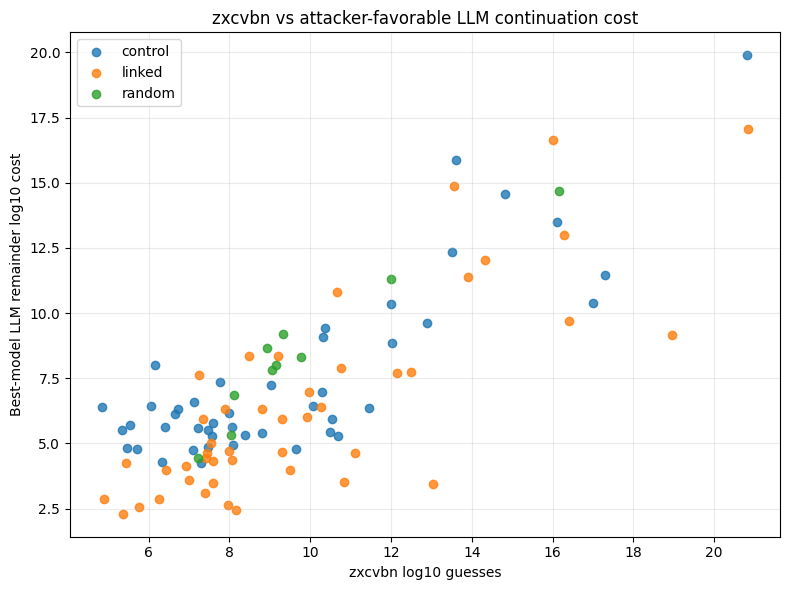

wrote results/figures/exp1d_two_model_side_by_side.png


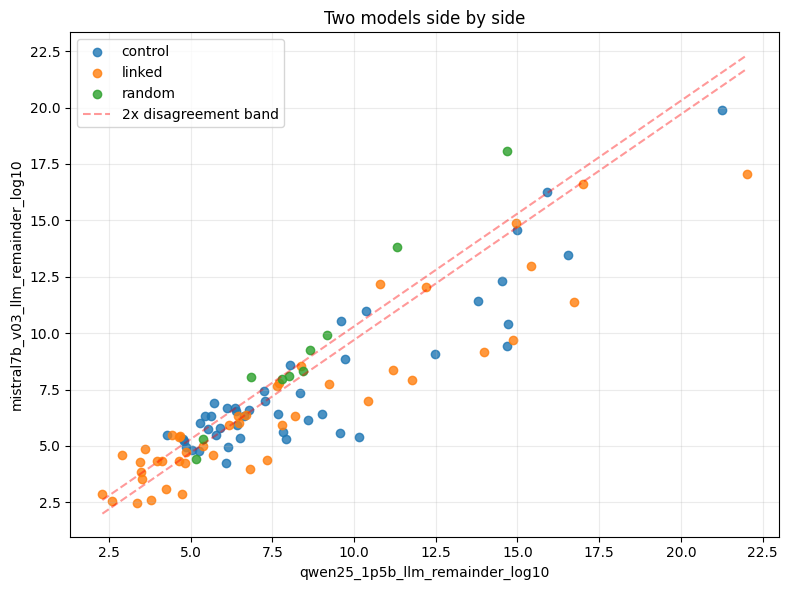

In [61]:

plt.figure(figsize=(8, 6))
for condition, g in df_wide.groupby("condition"):
    plt.scatter(g["zxcvbn_guesses_log10"], g["best_llm_remainder_log10"], label=condition, alpha=0.8)
plt.xlabel("zxcvbn log10 guesses")
plt.ylabel("Best-model LLM remainder log10 cost")
plt.title("zxcvbn vs attacker-favorable LLM continuation cost")
plt.legend()
plt.grid(True, alpha=0.25)
fig_path = Path("results/figures/exp1d_zxcvbn_vs_best_llm_log10.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=160)
print("wrote", fig_path)
plt.show()

if len(score_cols) == 2:
    xcol, ycol = score_cols
    plt.figure(figsize=(8, 6))
    for condition, g in df_wide.groupby("condition"):
        plt.scatter(g[xcol], g[ycol], label=condition, alpha=0.8)
    lo = min(df_wide[xcol].min(), df_wide[ycol].min())
    hi = max(df_wide[xcol].max(), df_wide[ycol].max())
    plt.plot([lo, hi], [lo+0.301, hi+0.301], linestyle="--", color="red", alpha=0.4)
    plt.plot([lo, hi], [lo-0.301, hi-0.301], linestyle="--", color="red", label="2x disagreement band", alpha=0.4)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title("Two models side by side")
    plt.legend()
    plt.grid(True, alpha=0.25)
    fig2_path = Path("results/figures/exp1d_two_model_side_by_side.png")
    plt.tight_layout()
    plt.savefig(fig2_path, dpi=160)
    print("wrote", fig2_path)
    plt.show()


In [62]:
mistral_truncated_count = df_raw[(df_raw['model_alias'] == 'mistral7b_v03') & (df_raw['truncated'] == True)].shape[0]
print(f"Number of passwords where Mistral DP truncated: {mistral_truncated_count}")

Number of passwords where Mistral DP truncated: 99


## Main output files

```text
results/exp1d_two_model_dp_raw.csv
results/exp1d_two_model_password_summary.csv
results/exp1d_two_model_condition_summary.csv
results/exp1d_two_model_family_summary.csv
results/exp1d_two_model_paired_linked_control.csv
results/figures/exp1d_zxcvbn_vs_best_llm_log10.png
results/figures/exp1d_two_model_side_by_side.png
```

Lower LLM log10 cost means the model finds the password remainder easier to continue.

`best_llm_remainder_log10` is the attacker-favorable score: if either model has the relevant cultural knowledge, this score listens to that model.

`uniform_mixture_llm_remainder_log10` treats the two models as an equal-weight mixture.

`best_plus_log10M_llm_remainder_log10` charges the attacker a small `log10(M)` overhead for trying multiple model streams.
